# Pruebas con modelos
---

**Autor:** Jaime Lozano Cillero

# 1. Elegir métrica principal

La clase positiva en esta clasificación es ``is_canceled=1``. Es decir, la reserva se cancela cuando ``is_canceled=1``.

El enunciado indica que el objetivo es predecir cuándo una reserva será cancelada. Lo que no concreta es cuál es la importancia de cada tipo de error para el hotel. Depende del negocio comunicar qué les produce mayor impacto negativo en su actividad. Por lo tanto, suponemos que el coste de ambos errores será comparable.

## Tipos de error

- Falsos positivo (error tipo I): Se predice que la reserva será cancelada pero el cliente se presenta en el hotel.
- Falsos negativos (error tipo II): Se predice que la reserva no será cancelada pero el cliente la cancela, o no se presenta.

## Métrica principal elegida

Elegimos **accuracy** porque mide la proporción de reservas clasificadas correctamente (verdaderos positivos y negativos) respecto al total de predicciones.

Accuracy = (TP + TN) / (TP + TN + FP + FN)

El hándicap sobre "accuracy" es que las clases estén muy desequilibradas. En este dataset se distribuyen en 37% y 63% aproximadamente; presentan ligero desequilibrio que no anula su aplicación.

# 2. Configuración

### Librerías y variables

In [2]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import tensorflow as tf

from typing import List, Optional, Tuple, Union

from matplotlib.colors import ListedColormap

from plotly.subplots import make_subplots
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder
)
from sklearn.metrics import (
    accuracy_score,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score
)

from lightgbm import LGBMClassifier

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

In [2]:
num_jobs = -1
cross_validation_count = 5
acortar_grid_search_cv = True

### Cargar datos

In [3]:
PATH_DIRECTORIO_DATOS = "../../data"
PATH_DATASET_PRACTICA_FINAL = f"{PATH_DIRECTORIO_DATOS}/processed/dataset_practica_final_preprocessed.csv"
PATH_DATASET_PROCESSED_REVISADO = f"{PATH_DIRECTORIO_DATOS}/processed/dataset_practica_final_preprocessed_revisado.csv"

# Cargamos el dataset de la práctica final
df = pd.read_csv(PATH_DATASET_PROCESSED_REVISADO)

# Al cargar los datos desde CSV, Pandas cambia el tipo de datos deseado.
dict_cast_category_cols = {
    'arrival_date_month': 'str',
    'agent' : 'str',
    'company' : 'str',
    'is_repeated_guest': 'str',
}
df = df.astype(dict_cast_category_cols)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119388 entries, 0 to 119387
Data columns (total 28 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119388 non-null  object 
 1   is_canceled                     119388 non-null  int64  
 2   lead_time                       119388 non-null  int64  
 3   arrival_date_year               119388 non-null  int64  
 4   arrival_date_month              119388 non-null  object 
 5   arrival_date_week_number        119388 non-null  int64  
 6   arrival_date_day_of_month       119388 non-null  int64  
 7   stays_in_weekend_nights         119388 non-null  int64  
 8   stays_in_week_nights            119388 non-null  int64  
 9   adults                          119388 non-null  int64  
 10  children                        119388 non-null  int64  
 11  babies                          119388 non-null  int64  
 12  meal            

In [5]:
# Definir variable objetivo
target_column = 'is_canceled'

# Definimos el índice de la clase cancelado
cancelado_idx = 1

# Diccionario de las categorías de la variable objetivo
dict_target_class_names = {
    0 : 'No cancelado',
    1 : 'Cancelado',
}

# Obtenemos la lista de nombres de las clases
list_target_class_names = dict_target_class_names.values()
list_target_class_names

dict_values(['No cancelado', 'Cancelado'])

## Crear conjuntos de datos train y test

In [6]:
X = df.drop(columns=target_column)
y = df[target_column]

categorical_columns = X.select_dtypes(include=["object"]).columns
numerical_columns = X.select_dtypes(include="number").columns


In [7]:
categorical_columns

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'is_repeated_guest', 'reserved_room_type',
       'deposit_type', 'agent', 'company', 'customer_type'],
      dtype='object')

In [8]:
numerical_columns

Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='object')

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
print(f"Recuento datos X_train: {len(X_train)}")
print(f"Recuento datos X_test:  {len(X_test)}")
print(f"Recuento datos y_train: {len(y_train)}")
print(f"Recuento datos y_test:  {len(y_test)}")

print(f"\nProporción de datos entre test y train:  {len(X_test) / (len(X_train) + len(X_test))}")

Recuento datos X_train: 95510
Recuento datos X_test:  23878
Recuento datos y_train: 95510
Recuento datos y_test:  23878

Proporción de datos entre test y train:  0.20000335042047776


## Distribución de clases en variable target (``is_canceled``)

Verificaremos que el ratio de clases de la variable ``is_canceled`` en el dataset también se mantiene en:
- conjunto de entrenamiento
- conjunto de prueba

In [11]:
print("Distribución de clases en el dataset")
print(y.value_counts(normalize=True))

print("\nDistribución de clases en el conjunto de entrenamiento")
print(y_train.value_counts(normalize=True))

print("\nDistribución de clases en el conjunto de prueba")
print(y_test.value_counts(normalize=True))

Distribución de clases en el dataset
is_canceled
0    0.629586
1    0.370414
Name: proportion, dtype: float64

Distribución de clases en el conjunto de entrenamiento
is_canceled
0    0.630112
1    0.369888
Name: proportion, dtype: float64

Distribución de clases en el conjunto de prueba
is_canceled
0    0.627481
1    0.372519
Name: proportion, dtype: float64


## Train-test split estratificado según la variable objetivo

In [12]:
# Se observa que el ratio difiere.
# Hacer train-test split utilizando stratify para que la proporción de clases se mantenga en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [13]:
print("Distribución de clases en el dataset")
print(y.value_counts(normalize=True))

print("\nDistribución de clases en el conjunto de entrenamiento")
print(y_train.value_counts(normalize=True))

print("\nDistribución de clases en el conjunto de prueba")
print(y_test.value_counts(normalize=True))

Distribución de clases en el dataset
is_canceled
0    0.629586
1    0.370414
Name: proportion, dtype: float64

Distribución de clases en el conjunto de entrenamiento
is_canceled
0    0.629589
1    0.370411
Name: proportion, dtype: float64

Distribución de clases en el conjunto de prueba
is_canceled
0    0.629575
1    0.370425
Name: proportion, dtype: float64


# Modelo Regresión Logística (la línea base)
---

In [ ]:
# Usar handle_unknown='infrequent_if_exist' para agrupar categorías con pocas apariciones
# Así evitamos errores de entrenamiento cuando aparece alguna categoría poco frecuente en validación
# pero no en entrenamiento.
prep_lr = ColumnTransformer([
    ('num', StandardScaler(), numerical_columns),
    ('cat', OneHotEncoder(sparse_output=False, handle_unknown='infrequent_if_exist'), categorical_columns),
])

pipe_lr = Pipeline([
    ('prep',  prep_lr),
    ('model', LogisticRegression(random_state=42, n_jobs=1)), # Paralelizar sólo en GridSearchCV
])

if acortar_grid_search_cv:
    grid_lr = GridSearchCV(
            pipe_lr,
            param_grid={
                'prep__cat__min_frequency': [20],
                'model__C': [10],
                'model__max_iter': [50],
                'model__solver': ['liblinear'],
            },
            cv=cross_validation_count,
            scoring='accuracy',
            n_jobs=num_jobs,
        )
else:
    grid_lr = GridSearchCV(
        pipe_lr,
        param_grid={
            'prep__cat__min_frequency': [5, 10, 20],
            'model__C': [0.1, 1, 10],
            'model__max_iter': [50, 100],
            'model__solver': ['liblinear'],
        },
        cv=cross_validation_count,
        scoring='accuracy',
        n_jobs=num_jobs,
    )
grid_lr.fit(X_train, y_train)


In [ ]:
# Mostramos los mejores hiperparámetros encontrados
print(f"Mejores hiperparámetros encontrados: {grid_lr.best_params_}")
print(f"Mejor score obtenido: {grid_lr.best_score_:.2%}")

**Log de mejores hiperparámetros encontrados para LogisticRegression**

{'model__C': 10, 'model__max_iter': 50, 'model__solver': 'liblinear', 'prep__cat__min_frequency': 20}
Mejor score obtenido: 83.01%


In [ ]:
modelo_lr = clone(grid_lr.best_estimator_)
modelo_lr.fit(X_train, y_train)

In [ ]:
# Predecir sobre el conjunto de test
y_pred = modelo_lr.predict(X_test)

# Obtenemos las probabilidades de pertenencia a la clase positiva (1)
# En este caso, la clase positiva es 'Cancelado'
y_proba = modelo_lr.predict_proba(X_test)[:, cancelado_idx]

# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Cálculo del AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_proba)

print(f"\nAccuracy:  {acc:.2%}")
print(f"Precisión: {prec:.2%}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

# Reporte detallado de las métricas de evaluación
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

In [ ]:
# Mostrar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No cancelado', 'Cancelado'])
disp.plot(cmap='Blues')
plt.show()

In [ ]:
# Mostrar la matriz de confusión normalizada
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No cancelado', 'Cancelado'])
disp.plot(cmap='Blues', values_format='.2%')
plt.show()

In [ ]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()

# Modelo Árbol de Decisión
---

In [ ]:
%%time

prep_dt = ColumnTransformer([
    ('num', 'passthrough', numerical_columns),
    ('cat', OneHotEncoder(sparse_output=False, handle_unknown='infrequent_if_exist'), categorical_columns),
])

pipe_dt = Pipeline([
    ('prep',  prep_dt),
    ('model', DecisionTreeClassifier(random_state=42)),
])

if acortar_grid_search_cv:
    grid_dt = GridSearchCV(
        pipe_dt,
        param_grid={
            'prep__cat__min_frequency': [10],
            'model__max_depth': [20],
            'model__min_samples_split': [5],
            'model__min_samples_leaf': [1],
        },
        cv=cross_validation_count,
        scoring='accuracy',
        n_jobs=num_jobs,
    )
else:
    grid_dt = GridSearchCV(
        pipe_dt,
        param_grid={
            'prep__cat__min_frequency': [5, 10, 20],
            'model__max_depth': [None, 5, 10, 20],
            'model__min_samples_split': [2, 5, 10],
            'model__min_samples_leaf': [1, 2, 4],
        },
        cv=cross_validation_count,
        scoring='accuracy',
        n_jobs=num_jobs,
    )
    
grid_dt.fit(X_train, y_train)

In [ ]:
# Mostramos los mejores hiperparámetros encontrados
print(f"Mejores hiperparámetros encontrados: {grid_dt.best_params_}")
print(f"Mejor score obtenido: {grid_dt.best_score_:.2%}")

**Log de mejores hiperparámetros encontrados para DecisionTreeClassifier**

{'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'prep__cat__min_frequency': 10}
Mejor score obtenido: 86.32%


In [ ]:
modelo_dt = clone(grid_dt.best_estimator_)
modelo_dt.fit(X_train, y_train)

# Hacemos predicciones sobre el conjunto de test
y_pred = modelo_dt.predict(X_test)

# Obtenemos las probabilidades de pertenencia a la clase positiva (1)
# En este caso, la clase positiva es 'Cancelado'
y_proba = modelo_dt.predict_proba(X_test)[:, cancelado_idx]

# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Cálculo del AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_proba)

print(f"\nAccuracy:  {acc:.2f}")
print(f"Precisión: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

# Reporte detallado de las métricas de evaluación
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

In [ ]:
# Hacemos predicciones sobre el conjunto de test
y_pred = modelo_dt.predict(X_test)

# Obtenemos las probabilidades de pertenencia a la clase positiva (1)
# En este caso, la clase positiva es 'Cancelado'
y_proba = modelo_dt.predict_proba(X_test)[:, cancelado_idx]

# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Cálculo del AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.2f}")
print(f"Precisión: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

# Reporte detallado de las métricas de evaluación
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

In [ ]:
# Mostrar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No cancelado', 'Cancelado'])
disp.plot(cmap='Blues')
plt.show()

In [ ]:
# Mostrar la matriz de confusión normalizada
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No cancelado', 'Cancelado'])
disp.plot(cmap='Blues', values_format='.2%')
plt.show()

In [ ]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()

# Modelo Random Forest
---

In [ ]:
%%time

prep_rfc = ColumnTransformer([
    ('num', 'passthrough', numerical_columns),
    ('cat', OneHotEncoder(sparse_output=False, handle_unknown='infrequent_if_exist'), categorical_columns),
])

pipe_rfc = Pipeline([
    ('prep',  prep_rfc),
    ('model', RandomForestClassifier(random_state=42, n_jobs=1)), # Paralelizar sólo en GridSearchCV
])

if acortar_grid_search_cv:
    grid_rfc = GridSearchCV(
        pipe_rfc,
        param_grid={
            'prep__cat__min_frequency': [20],
            'model__n_estimators': [200],
            'model__max_depth': [None],
            'model__min_samples_split': [2],
            'model__min_samples_leaf': [1],
        },
        cv=cross_validation_count,
        scoring='accuracy',
        n_jobs=num_jobs,
    )
else:
    grid_rfc = GridSearchCV(
        pipe_rfc,
        param_grid={
            'prep__cat__min_frequency': [5, 10, 20],
            'model__n_estimators': [100, 200],
            'model__max_depth': [None, 5, 10, 20],
            'model__min_samples_split': [2, 5, 10],
            'model__min_samples_leaf': [1, 2, 4],
        },
        cv=cross_validation_count,
        scoring='accuracy',
        n_jobs=num_jobs,
    )

grid_rfc.fit(X_train, y_train)

In [ ]:
# Mostramos los mejores hiperparámetros encontrados
print(f"Mejores hiperparámetros encontrados: {grid_rfc.best_params_}")
print(f"Mejor score obtenido: {grid_rfc.best_score_:.2%}")

**Log de mejores hiperparámetros encontrados para RandomForestClassifier**

{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200, 'prep__cat__min_frequency': 20}
Mejor score obtenido: 89.04%


In [ ]:
modelo_rfc = clone(grid_rfc.best_estimator_)
modelo_rfc.fit(X_train, y_train)

# Hacemos predicciones sobre el conjunto de test
y_pred = modelo_rfc.predict(X_test)

# Obtenemos las probabilidades de pertenencia a la clase positiva (1)
# En este caso, la clase positiva es 'Cancelado'
y_proba = modelo_rfc.predict_proba(X_test)[:, cancelado_idx]

In [ ]:
# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Cálculo del AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.2f}")
print(f"Precisión: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

# Reporte detallado de las métricas de evaluación
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

In [ ]:
# Mostrar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No cancelado', 'Cancelado'])
disp.plot(cmap='Blues')
plt.show()

In [ ]:
# Mostrar la matriz de confusión normalizada
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No cancelado', 'Cancelado'])
disp.plot(cmap='Blues', values_format='.2%')
plt.show()

In [ ]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()

#### Gráfico de importancia de variables

In [ ]:
# Importancia de variables
col_importancia_rfc = modelo_rfc.named_steps['model'].feature_importances_
col_nombres = modelo_rfc.named_steps['prep'].get_feature_names_out()

df_importances_rfc = pd.DataFrame({
    'variable' : col_nombres,
    'importancia' : col_importancia_rfc
}).sort_values('importancia', ascending=False).reset_index(drop=True)

In [ ]:
df_importances_rfc.head(20)

Llama la atención que pesen tanto valores concretos de ciertas categóricas:
- ``cat__country_PRT`` es el país Portugal.

In [ ]:
# Al hacer one-hot encoding, cada valor de las columnas categóricas pasa a ocupar su propia columna.
# Agregar las importancias por el nombre de la variable original.

def variable_original(nombre):
    bloque, resto = nombre.split('__', 1)
    if bloque == 'num':
        return resto
    # 'cat': la columna categórica más larga que sea prefijo del nombre de la dummy
    candidatas = [col for col in categorical_columns if resto.startswith(col + '_')]
    return max(candidatas, key=len) if candidatas else resto

df_importances_rfc['variable_original'] = df_importances_rfc['variable'].apply(variable_original)

df_importances_rfc_agr = (
    df_importances_rfc
    .groupby('variable_original', as_index=False)['importancia']
    .sum()
    .sort_values('importancia', ascending=False)
    .reset_index(drop=True)
)

df_importances_rfc_agr

In [ ]:
# Comprobar que la suma de todas las importancias es 1.
df_importances_rfc_agr['importancia'].sum()

In [ ]:
# Ordenamos el dataframe por la importancia de manera descendente
#df_importances_rfc_agr = df_importances_rfc_agr.sort_values(by='importancia', ascending=False)

# Visualización de la importancia de las variables
fig = px.bar(
    df_importances_rfc_agr,
    x='importancia',
    y='variable_original',
    text='importancia',
    text_auto=".3%",
    title='Importancia de las variables en el modelo Random Forest Classifier',
    labels={'x': 'Importancia', 'y': 'Variable'},
    width=700, height=700
)
fig.update_layout(xaxis_tickangle=-45)
fig.show(renderer='iframe')

# Modelo Gradient Boosting - LightGBM
---

In [ ]:
prep_lgbm = ColumnTransformer([
    ('num', 'passthrough', numerical_columns),
    ('cat', OneHotEncoder(sparse_output=False, handle_unknown='infrequent_if_exist'), categorical_columns),
]).set_output(transform='pandas') # Para que a LightGBM le lleguen los nombre de las columnas

pipe_lgbm = Pipeline([
    ('prep',  prep_lgbm),
    ('model', LGBMClassifier(
        random_state=42,
        max_depth=-1, # No limitar la profundidad porque está relacionada con el número de hojas posibles
        n_jobs=1, # Paralelizar sólo en GridSearchCV
    )), 
])

if acortar_grid_search_cv:
    grid_lgbm = GridSearchCV(
        pipe_lgbm,
        param_grid={
            'prep__cat__min_frequency': [10],
            'model__n_estimators': [500],
            'model__num_leaves': [127],
            'model__learning_rate': [0.1],
            'model__min_child_samples': [20],
            'model__subsample': [0.8],
            'model__subsample_freq': [1],
            'model__colsample_bytree': [1.0],
        },
        cv=cross_validation_count,
        scoring='accuracy',
        n_jobs=num_jobs,
    )
else:
    grid_lgbm = GridSearchCV(
        pipe_lgbm,
        param_grid={
            'prep__cat__min_frequency': [5, 10, 20],
            'model__n_estimators': [200, 500],
            'model__num_leaves': [31, 63, 127],
            'model__learning_rate': [0.05, 0.1],
            'model__min_child_samples': [20, 50],
            'model__subsample': [0.8, 1.0],
            'model__subsample_freq': [1],
            'model__colsample_bytree': [0.8, 1.0],
        },
        cv=cross_validation_count,
        scoring='accuracy',
        n_jobs=num_jobs,
    )

grid_lgbm.fit(X_train, y_train)

In [ ]:
# Visualizar los mejores hiperparámetros encontrados
print(f"Mejores hiperparámetros encontrados: {grid_lgbm.best_params_}")
print(f"Mejor score obtenido: {grid_lgbm.best_score_:.2%}")

**Log de mejores hiperparámetros encontrados para Gradient Boosting LGBMClassifier**

{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__min_child_samples': 20, 'model__n_estimators': 500, 'model__num_leaves': 127, 'model__subsample': 0.8, 'model__subsample_freq': 1, 'prep__cat__min_frequency': 10}
Mejor score obtenido: 88.90%


In [ ]:
modelo_lgbm = clone(grid_lgbm.best_estimator_)
modelo_lgbm.fit(X_train, y_train)

# Hacemos predicciones sobre el conjunto de test
y_pred = modelo_lgbm.predict(X_test)

# Obtenemos las probabilidades de pertenencia a la clase positiva (1)
# En este caso, la clase positiva es 'Cancelado'
y_proba = modelo_lgbm.predict_proba(X_test)[:, cancelado_idx]

# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Cálculo del AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.2f}")
print(f"Precisión: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

# Reporte detallado de las métricas de evaluación
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

In [ ]:
# Mostrar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No cancelado', 'Cancelado'])
disp.plot(cmap='Blues')
plt.show()

In [ ]:
# Mostrar la matriz de confusión normalizada
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No cancelado', 'Cancelado'])
disp.plot(cmap='Blues', values_format='.2%')
plt.show()

In [ ]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()

# Red neuronal multicapa usando Keras de TensorFlow
---

In [14]:
prep_keras = ColumnTransformer([
    ('num', StandardScaler(), numerical_columns),
    ('cat', OneHotEncoder(
        sparse_output=False,
        handle_unknown='infrequent_if_exist',
        min_frequency=20, # Mantener el valor más frecuente al entrenar el resto de algoritmos
    ), categorical_columns),
])

# Aplicar la transformación a las columnas categóricas y numéricas
X_train_transformed = prep_keras.fit_transform(X_train)
X_test_transformed = prep_keras.transform(X_test)

# Definir la arquitectura del modelo
modelo_keras = models.Sequential([
    layers.Input(shape=(X_train_transformed.shape[1], ), name='i1'),
    layers.Dense(128, activation='relu', name='h1'),
    layers.Dropout(0.2), # Capa de Dropout para regularización
    layers.Dense(64, activation='relu', name='h2'),
    layers.Dropout(0.2), # Capa de Dropout para regularización
    layers.Dense(32, activation='relu', name='h3'),
    layers.Dropout(0.2), # Capa de Dropout para regularización
    layers.Dense(1, activation='sigmoid', name='o1')
])

# Compilar el modelo
optimizer_adam = tf.keras.optimizers.Adam(learning_rate=0.01)
modelo_keras.compile(optimizer=optimizer_adam, loss='binary_crossentropy', metrics=['accuracy'])

# Mostrar un resumen del modelo
modelo_keras.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ h1 (Dense)                      │ (None, 128)            │        46,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h2 (Dense)                      │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h3 (Dense)                      │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ o1 (Dense)                      │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,217 (223.50 KB)

 Trainable params: 57,217 (223.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
%%time

# Entrenamos el modelo y guardamos el historial para visualizar el aprendizaje
history_keras = modelo_keras.fit(
    X_train_transformed,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

In [ ]:
# Evaluamos el modelo en el conjunto de prueba
loss_keras, accuracy_keras = modelo_keras.evaluate(X_test_transformed, y_test)
print(f"Test Loss: {loss_keras:.4f}, Test Accuracy: {accuracy_keras:.4f}")

In [ ]:
# Mostrar la función de coste del modelo
plt.plot(history_keras.history['loss'], label='Acc train')
plt.plot(history_keras.history['val_loss'], label='Acc val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Curva de aprendizaje')
plt.legend()
plt.show()

### EarlyStopping para Keras

In [15]:
# Definimos un callback de EarlyStopping para detener el entrenamiento si no hay mejora en la validación
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitorea la pérdida de validación
    patience=10,         # Número de épocas sin mejora antes de detener el entrenamiento
    restore_best_weights=True  # Restaura los mejores pesos del modelo
)

In [16]:
%%time
# Entrenar el modelo y guardar el historial para visualizar el aprendizaje
history_early = modelo_keras.fit(X_train_transformed, y_train, epochs=100, validation_split=0.2, verbose=1, callbacks=[early_stopping])

# Entrenar el modelo con EarlyStopping y guardar el historial para visualizar el aprendizaje
history_keras = modelo_keras.fit(
    X_train_transformed,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8138 - loss: 0.3862 - val_accuracy: 0.8453 - val_loss: 0.3210
Epoch 2/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8467 - loss: 0.3293 - val_accuracy: 0.8560 - val_loss: 0.3091
Epoch 3/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8506 - loss: 0.3181 - val_accuracy: 0.8576 - val_loss: 0.3158
Epoch 4/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8508 - loss: 0.3148 - val_accuracy: 0.8573 - val_loss: 0.3044
Epoch 5/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8542 - loss: 0.3145 - val_accuracy: 0.8604 - val_loss: 0.2997
Epoch 6/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8543 - loss: 0.3096 - val_accuracy: 0.8561 - val_loss: 0.3026
Epoch 7/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8518 - loss: 0.3119 - val_accuracy: 0.8602 - val_loss: 0.2976
Epoch 8/100
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8571 - loss: 0

In [17]:
# Evaluamos el modelo en el conjunto de prueba
loss_keras, accuracy_keras = modelo_keras.evaluate(X_test_transformed, y_test)
print(f"Test Loss: {loss_keras:.4f}, Test Accuracy: {accuracy_keras:.4f}")

747/747 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8634 - loss: 0.2924
Test Loss: 0.2919, Test Accuracy: 0.8626


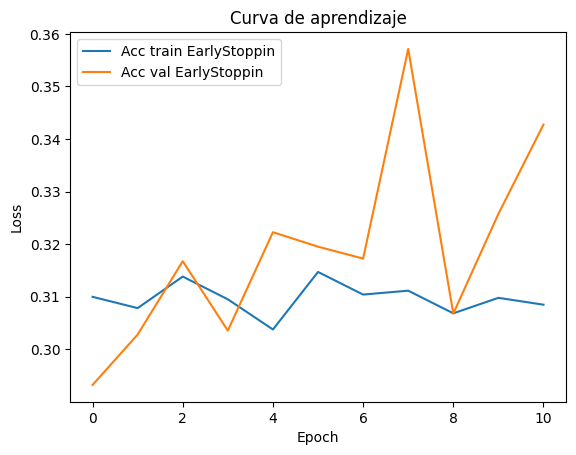

In [18]:
# Mostrar la función de coste del modelo con EarlyStopping
plt.plot(history_keras.history['loss'], label='Acc train EarlyStoppin')
plt.plot(history_keras.history['val_loss'], label='Acc val EarlyStoppin')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Curva de aprendizaje')
plt.legend()
plt.show()

---

In [19]:
# Hacer predicciones y convertir probabilidades a 0/1
y_pred_prob = modelo_keras.predict(X_test_transformed)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

747/747 ━━━━━━━━━━━━━━━━━━━━ 1s 999us/step


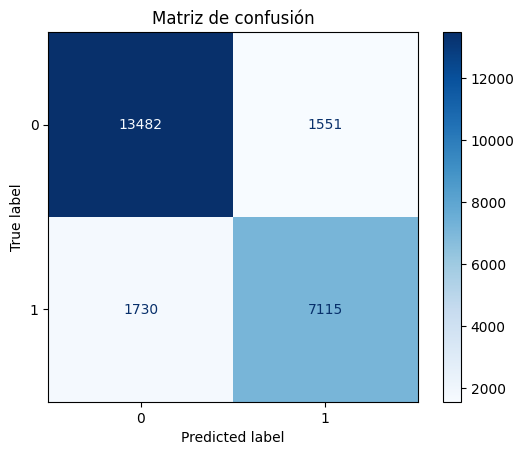

In [20]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Matriz de confusión')
plt.show()

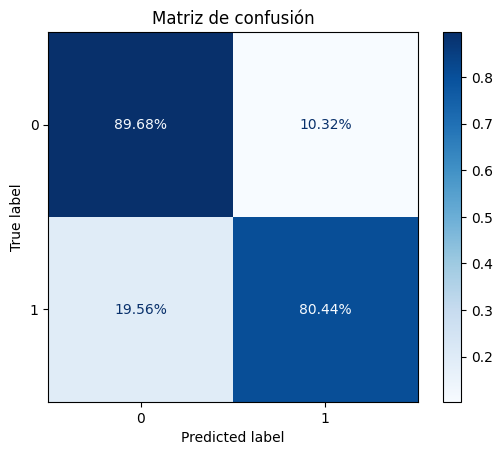

In [21]:
# Matriz de confusión normalizada
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='.2%')
plt.title('Matriz de confusión')
plt.show()

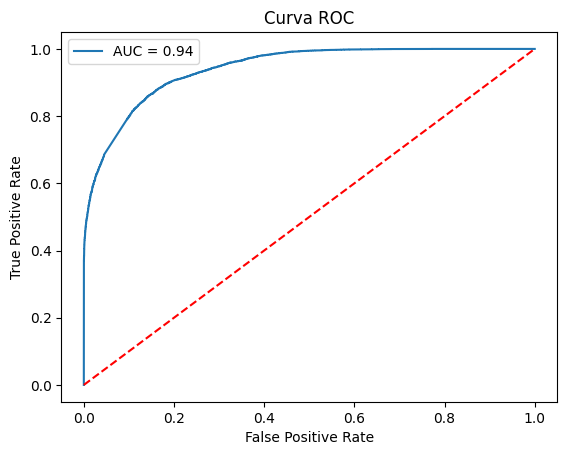

In [22]:
# Obtenemos la curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label='AUC = {:.2f}'.format(roc_auc))
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.show()

In [23]:
print(f"ROC-AUC: {roc_auc:.5f}")

ROC-AUC: 0.94124


In [ ]:
print("Evaluando 'accuracy' en Keras con EarlyStopping:", modelo_keras.evaluate(X_test_transformed, y_test, verbose=0)[1])

Evaluando 'accuracy' con EarlyStopping: 0.8625931739807129
